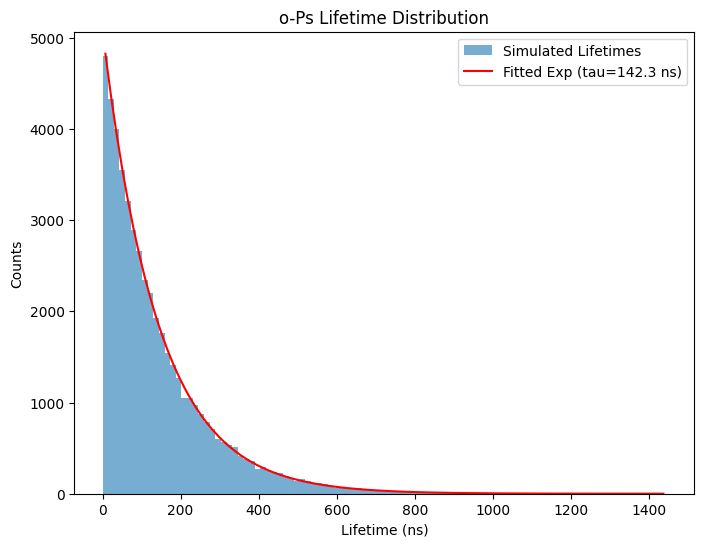

Lifetime Verification: Fitted tau = 142.3 ns (expected 142 ns). Chi2 p-value = 0.066 (good if >0.05)


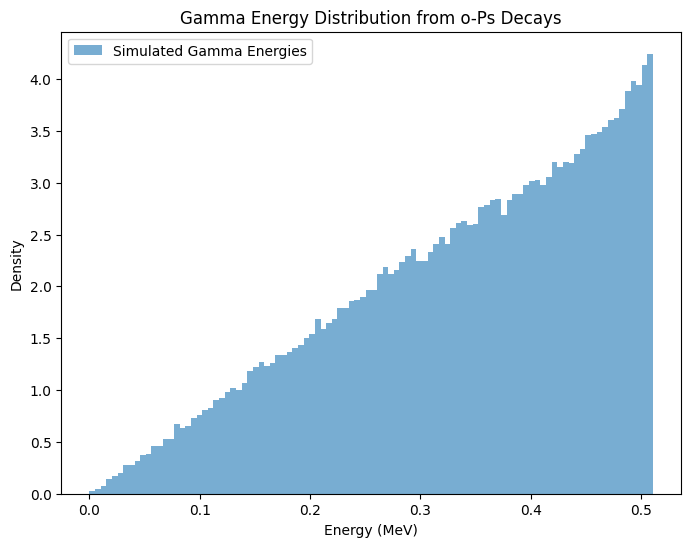

Energy Verification: Mean gamma E = 0.3407 MeV (expected ~0.3407 MeV)


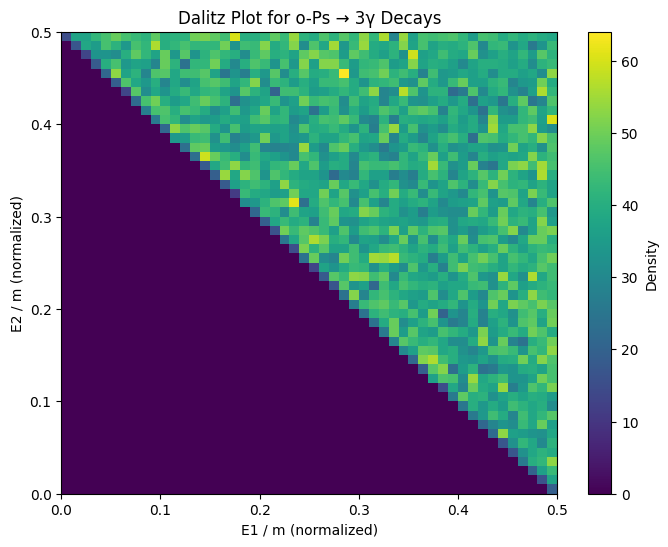

Dalitz Verification: 50000 valid 3-gamma events. Edge enhancement count (rough): 18001 (expect higher density near axes)


In [8]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chisquare

# Define constants
M_2ME = 1.022  # MeV (2 * m_e c^2)
O_PS_MEAN_LIFETIME = 142.0  # ns (expected mean for o-Ps in vacuum)

# Load ROOT file (adjust path if needed)
file_path = "oPs.root"  # Replace with your actual file
root_file = uproot.open(file_path)

# Assume ntuple names based on code: TruthPs (index 4), TruthGamma (index 5)
truth_ps = root_file["TruthPs"]  # Adjust key if different
truth_gamma = root_file["TruthGamma"]

# Extract arrays (adjust branch names based on your ntuple columns)
# For TruthPs: EventID, TrackID, ParentID, Type, ..., Lifetime_ns (column 13)
ps_event_id = truth_ps["EventID"].array()
ps_track_id = truth_ps["TrackID"].array()
ps_type = truth_ps["Type"].array()  # Assuming string array for "o-Ps"
ps_lifetime = truth_ps["Lifetime_ns"].array()  # Your new column

# For TruthGamma: EventID, TrackID, ParentID, Type, Energy_MeV, ...
gamma_event_id = truth_gamma["EventID"].array()
gamma_track_id = truth_gamma["TrackID"].array()
gamma_parent_id = truth_gamma["ParentID"].array()
gamma_type = truth_gamma["Type"].array()  # "PsDecay"
gamma_energy = truth_gamma["Energy_MeV"].array()

# Filter for o-Ps only
o_ps_mask = (ps_type == "o-Ps")
o_ps_lifetimes = ps_lifetime[o_ps_mask]
o_ps_track_ids = ps_track_id[o_ps_mask]  # For correlating with gammas

# 1. Verify o-Ps Lifetime Distribution
# Histogram and fit exponential: f(t) = (1/tau) * exp(-t/tau)
def exp_func(t, tau):
    return (1 / tau) * np.exp(-t / tau)

plt.figure(figsize=(8, 6))
counts, bins, _ = plt.hist(o_ps_lifetimes, bins=100, density=False, alpha=0.6, label="Simulated Lifetimes")  # Use counts
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = np.diff(bins)[0]

# Fit to density
hist_density = counts / (np.sum(counts) * bin_width)
popt, _ = curve_fit(exp_func, bin_centers, hist_density, p0=[O_PS_MEAN_LIFETIME])
fitted_tau = popt[0]
plt.plot(bin_centers, exp_func(bin_centers, *popt) * (np.sum(counts) * bin_width), 'r-', label=f"Fitted Exp (tau={fitted_tau:.1f} ns)")  # Scale fit to counts for plot
plt.xlabel("Lifetime (ns)")
plt.ylabel("Counts")
plt.title("o-Ps Lifetime Distribution")
plt.legend()
plt.show()

# Chi-square test: Use counts and scaled expected
expected = exp_func(bin_centers, *popt) * (np.sum(counts) * bin_width)  # Scale to match total observed sum

# Normalize expected to exactly match sum of observed (to avoid ValueError due to floating-point mismatch)
mask = expected > 0
expected[mask] *= np.sum(counts[mask]) / np.sum(expected[mask])

chi2, p_value = chisquare(counts[mask], expected[mask], ddof=1)  # ddof=1 for 1 param fit
print(f"Lifetime Verification: Fitted tau = {fitted_tau:.1f} ns (expected 142 ns). Chi2 p-value = {p_value:.3f} (good if >0.05)")

# 2. Verify Energy Distribution (single gamma energies from o-Ps decays)
# Filter gammas from o-Ps decays (Type="PsDecay", ParentID in o_ps_track_ids)
ps_decay_mask = (gamma_type == "PsDecay") & np.isin(gamma_parent_id, o_ps_track_ids)
gamma_energies_ops = gamma_energy[ps_decay_mask]

plt.figure(figsize=(8, 6))
plt.hist(gamma_energies_ops, bins=100, range=(0, 0.511), density=True, alpha=0.6, label="Simulated Gamma Energies")
plt.xlabel("Energy (MeV)")
plt.ylabel("Density")
plt.title("Gamma Energy Distribution from o-Ps Decays")
plt.legend()
plt.show()

# Theoretical: For 3-body decay, single gamma PDF ~ (1 - 2E/m) for E in [0, m/2], but integrated over phase space
# Simple check: Mean should be ~1.022 / 3 ≈ 0.3407 MeV
sim_mean = np.mean(gamma_energies_ops)
print(f"Energy Verification: Mean gamma E = {sim_mean:.4f} MeV (expected ~0.3407 MeV)")

# 3. Verify Dalitz Plot
# Group gammas by event, filter to exactly 3 per o-Ps decay event
unique_events = np.unique(gamma_event_id[ps_decay_mask])
dalitz_x = []
dalitz_y = []

for evt in unique_events:
    event_mask = (gamma_event_id == evt) & ps_decay_mask
    energies = gamma_energy[event_mask]
    if len(energies) == 3:  # o-Ps: exactly 3 gammas
        #sorted_e = np.sort(energies)
        dalitz_x.append(energies[0] / M_2ME)
        dalitz_y.append(energies[1] / M_2ME)

plt.figure(figsize=(8, 6))
plt.hist2d(dalitz_x, dalitz_y, bins=50, range=[[0, 0.5], [0, 0.5]], cmap="viridis")
plt.colorbar(label="Density")
plt.xlabel("E1 / m (normalized)")
plt.ylabel("E2 / m (normalized)")
plt.title("Dalitz Plot for o-Ps → 3γ Decays")
plt.show()

# Simple verification: Check sum per event ~1.0 normalized
# Theoretical density higher near boundaries—visual inspect or compute edge/center ratio
edge_count = np.sum((np.array(dalitz_x) < 0.1) | (np.array(dalitz_y) > 0.4))  # Rough
print(f"Dalitz Verification: {len(dalitz_x)} valid 3-gamma events. Edge enhancement count (rough): {edge_count} (expect higher density near axes)")